# 7. Análise Comparativa de Todos os Modelos

## Objetivo
Realizar uma análise comparativa abrangente de todos os modelos treinados, incluindo:
1. Comparação de métricas de desempenho (F1-Score, ROC-AUC, Acurácia, Precisão, Recall)
2. Curvas ROC sobrepostas para comparação visual
3. Curvas Precision-Recall sobrepostas
4. Matrizes de confusão lado a lado
5. Validação cruzada comparativa (5-fold Stratified)
6. Teste estatístico de Friedman para significância das diferenças
7. Ranking final dos modelos

## Modelos Comparados
- Random Forest (Breiman, 2001)
- XGBoost (Chen & Guestrin, 2016)
- SVM (Cortes & Vapnik, 1995)
- LightGBM (Ke et al., 2017)
- MLP (Rumelhart et al., 1986)
- LASSO (Tibshirani, 1996)

## 1. Importações e Configurações

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
import joblib
from scipy import stats

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score, auc
)

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

os.makedirs('../graficos', exist_ok=True)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados e Modelos

In [18]:
# Carregar dados
with open('../dados/processados/datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

X_train = datasets['baseline']['X_train']
X_test = datasets['baseline']['X_test']
y_train = datasets['baseline']['y_train']
y_test = datasets['baseline']['y_test']

# Carregar modelos treinados
model_files = {
    'Random Forest': '../modelos/random_forest_model.pkl',
    'XGBoost': '../modelos/xgboost_model.pkl',
    'SVM': '../modelos/svm_model.pkl',
    'LightGBM': '../modelos/lightgbm_model.pkl',
    'MLP': '../modelos/mlp_model.pkl',
    'LASSO': '../modelos/lasso_model.pkl'
}

models = {}
for name, path in model_files.items():
    if os.path.exists(path):
        models[name] = joblib.load(path)
        print(f'  [OK] {name} carregado')
    else:
        print(f'  [!!] {name} não encontrado em {path}')

print(f'\nTotal de modelos carregados: {len(models)}')
print(f'Dados: X_train={X_train.shape}, X_test={X_test.shape}')

  [OK] Random Forest carregado
  [OK] XGBoost carregado
  [OK] SVM carregado
  [OK] LightGBM carregado
  [OK] MLP carregado
  [OK] LASSO carregado

Total de modelos carregados: 6
Dados: X_train=(1730, 50), X_test=(372, 50)


## 3. Cálculo de Métricas para Todos os Modelos

In [19]:
# Calcular métricas para cada modelo
all_metrics = []
all_predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc_val = auc(rec_vals, prec_vals)
    
    metrics = {
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
        'PR-AUC': pr_auc_val
    }
    all_metrics.append(metrics)
    all_predictions[name] = {'y_pred': y_pred, 'y_pred_proba': y_pred_proba}

df_metrics = pd.DataFrame(all_metrics).set_index('Modelo')
df_metrics = df_metrics.sort_values('F1-Score', ascending=False)

print('=' * 80)
print('TABELA COMPARATIVA DE MÉTRICAS - CONJUNTO DE TESTE')
print('=' * 80)
print(df_metrics.round(4).to_string())
print('=' * 80)

TABELA COMPARATIVA DE MÉTRICAS - CONJUNTO DE TESTE
               Acurácia  Precisão  Recall  F1-Score  ROC-AUC  PR-AUC
Modelo                                                              
SVM              0.5699    0.5634  0.9756    0.7143   0.6411  0.6871
MLP              0.5511    0.5511  1.0000    0.7106   0.4763  0.5302
Random Forest    0.6371    0.6367  0.7951    0.7072   0.7034  0.7333
XGBoost          0.6102    0.6064  0.8341    0.7023   0.6574  0.6921
LightGBM         0.5941    0.5964  0.8146    0.6887   0.6703  0.6967
LASSO            0.5833    0.6276  0.6000    0.6135   0.6143  0.6313


## 4. Visualizações Comparativas

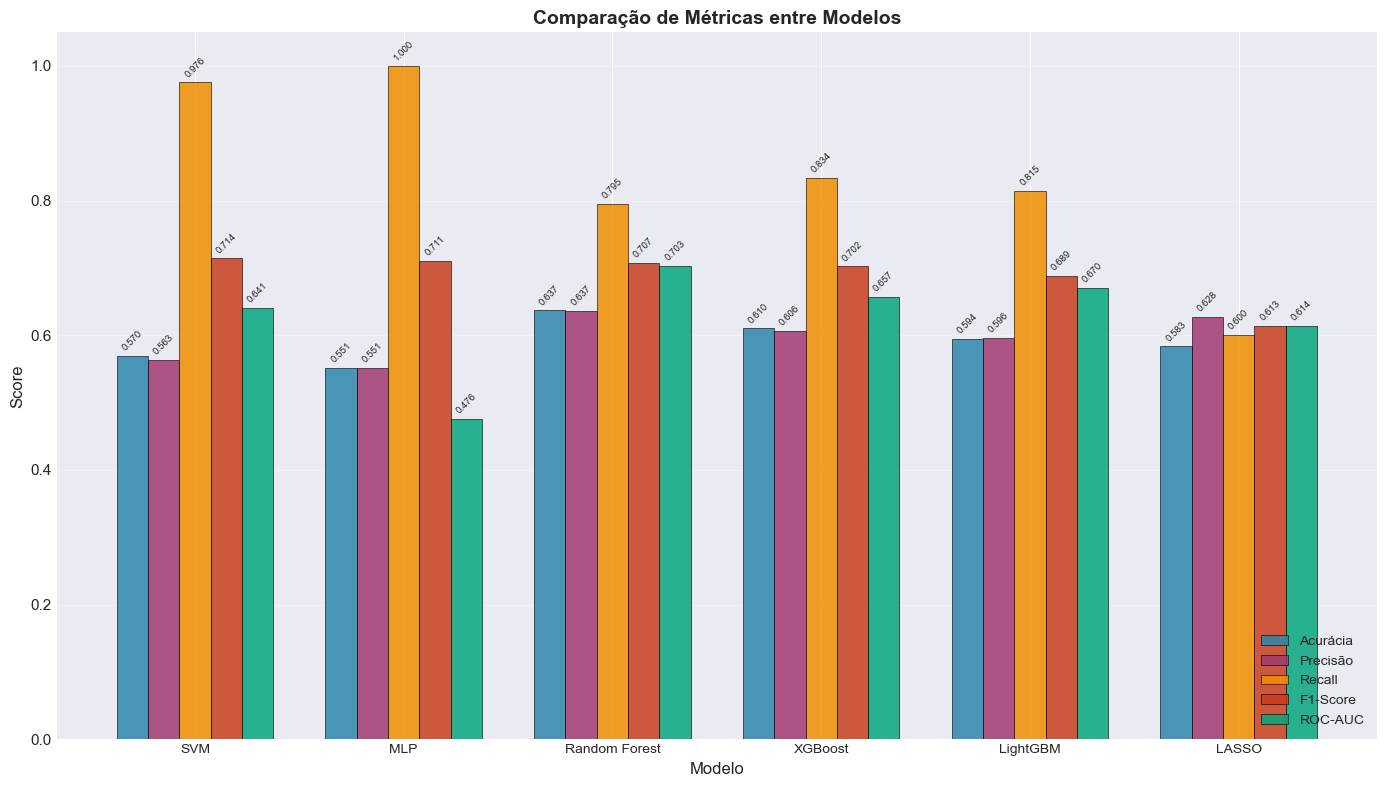

Gráfico salvo: ../graficos/07_comparacao_metricas.png


In [20]:
# 4.1 Gráfico de Barras Comparativo de Métricas
fig, ax = plt.subplots(figsize=(14, 8))
df_plot = df_metrics[['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'ROC-AUC']]
x = np.arange(len(df_plot.index))
width = 0.15
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#06A77D']

for i, (col, color) in enumerate(zip(df_plot.columns, colors)):
    bars = ax.bar(x + i * width, df_plot[col].values, width, label=col, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, df_plot[col].values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, f'{val:.3f}',
                ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparação de Métricas entre Modelos', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_plot.index, fontsize=10)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/07_comparacao_metricas.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/07_comparacao_metricas.png')

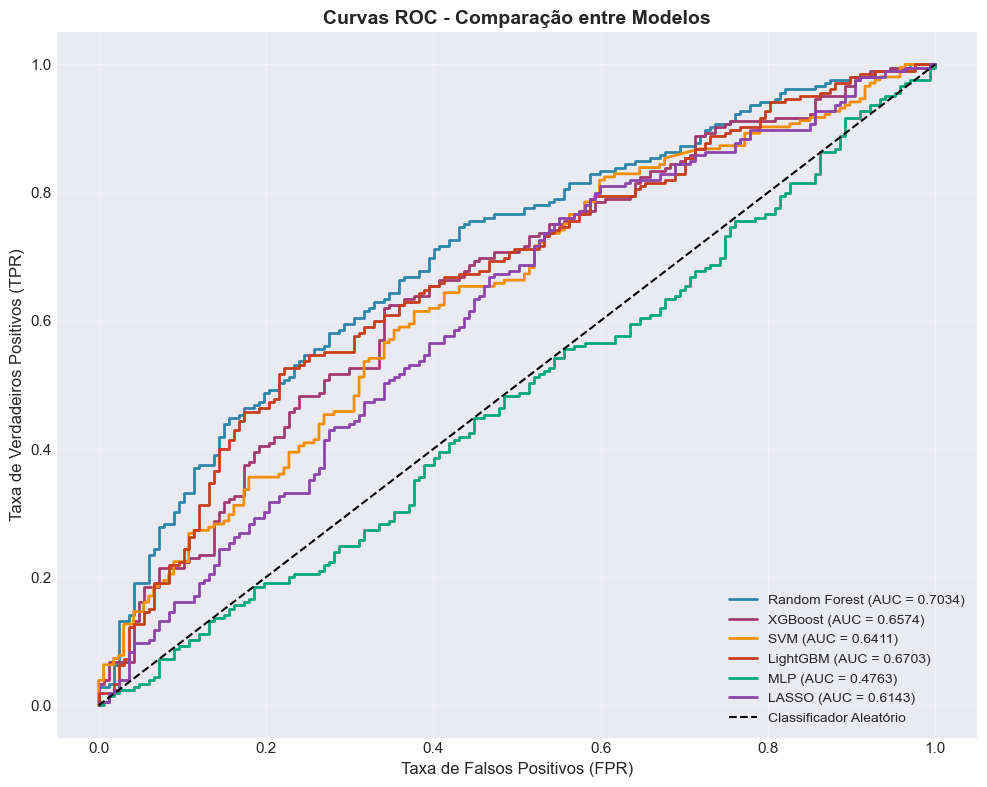

Gráfico salvo: ../graficos/07_curvas_roc_comparacao.png


In [21]:
# 4.2 Curvas ROC Sobrepostas
fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#06A77D', '#8E44AD']

for (name, preds), color in zip(all_predictions.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, preds['y_pred_proba'])
    roc_auc_val = roc_auc_score(y_test, preds['y_pred_proba'])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_val:.4f})', linewidth=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Classificador Aleatório')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC - Comparação entre Modelos', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/07_curvas_roc_comparacao.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/07_curvas_roc_comparacao.png')

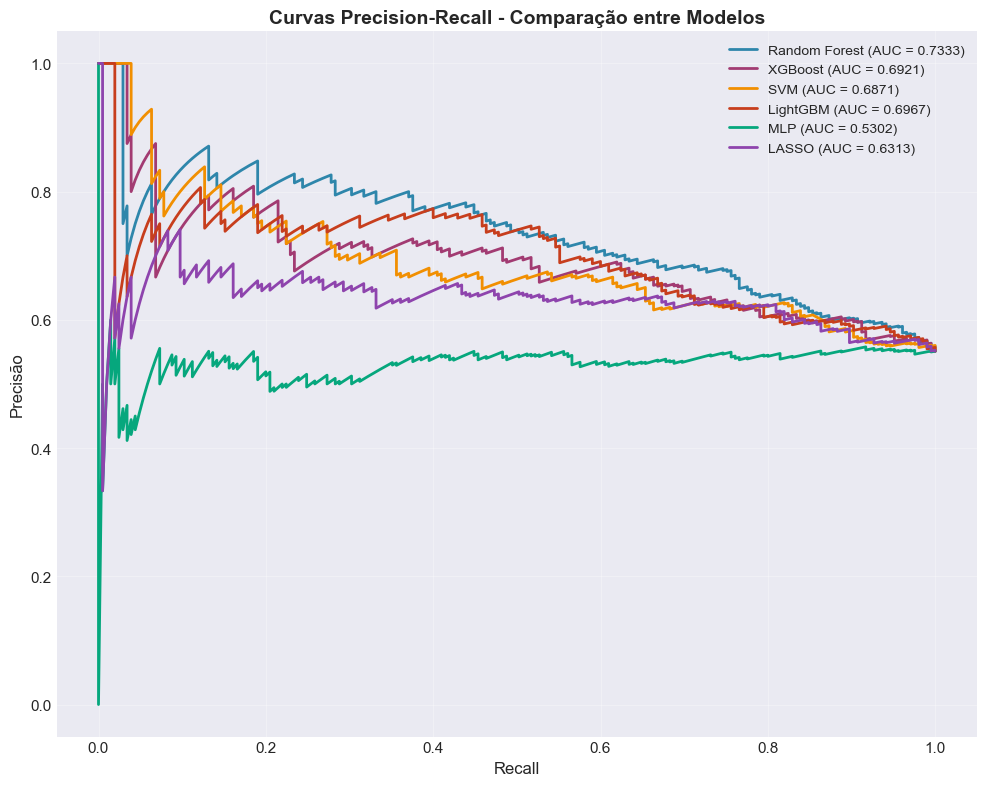

Gráfico salvo: ../graficos/07_curvas_pr_comparacao.png


In [22]:
# 4.3 Curvas Precision-Recall Sobrepostas
fig, ax = plt.subplots(figsize=(10, 8))

for (name, preds), color in zip(all_predictions.items(), colors_roc):
    prec, rec, _ = precision_recall_curve(y_test, preds['y_pred_proba'])
    pr_auc_val = auc(rec, prec)
    ax.plot(rec, prec, label=f'{name} (AUC = {pr_auc_val:.4f})', linewidth=2, color=color)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precisão', fontsize=12)
ax.set_title('Curvas Precision-Recall - Comparação entre Modelos', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/07_curvas_pr_comparacao.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/07_curvas_pr_comparacao.png')

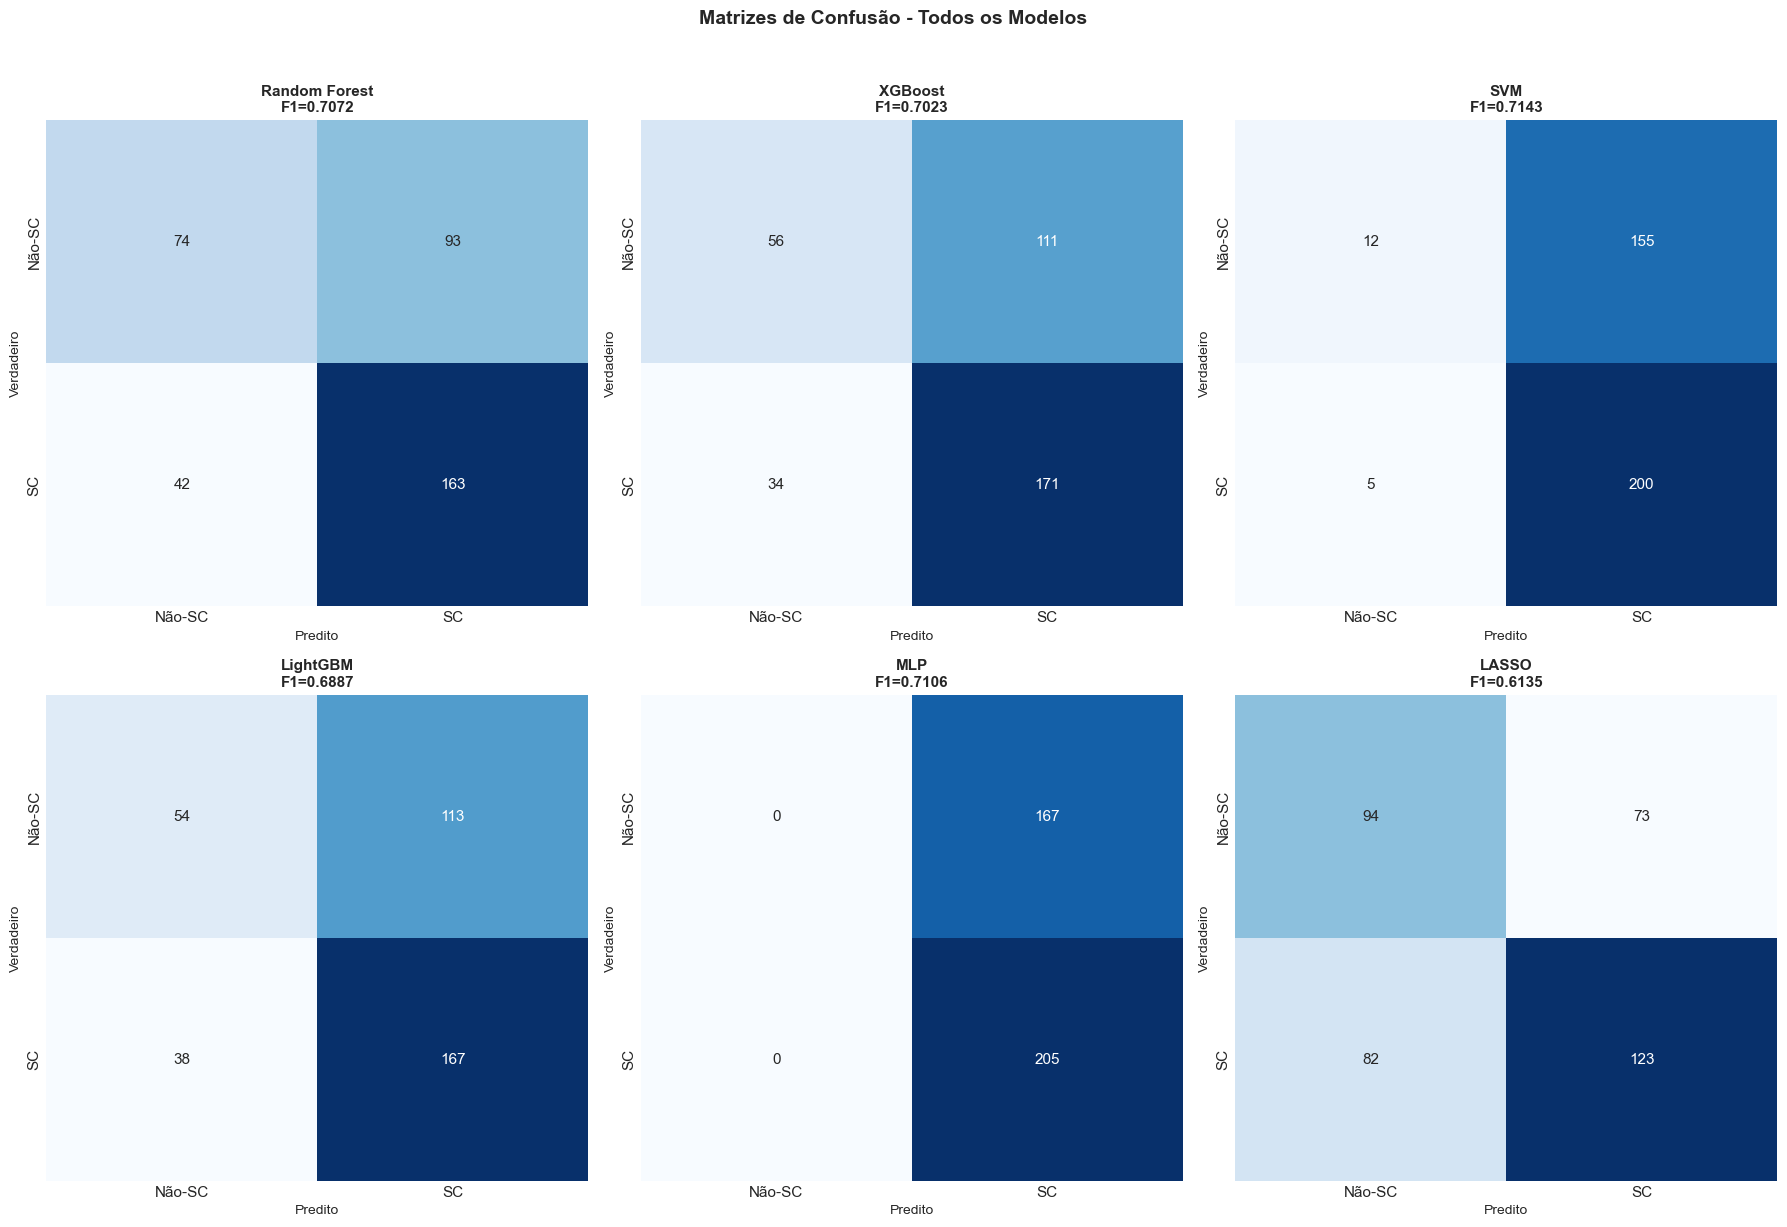

Gráfico salvo: ../graficos/07_matrizes_confusao.png


In [23]:
# 4.4 Matrizes de Confusão Lado a Lado
n_models = len(models)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, preds) in enumerate(all_predictions.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Não-SC', 'SC'], yticklabels=['Não-SC', 'SC'])
    ax.set_ylabel('Verdadeiro', fontsize=10)
    ax.set_xlabel('Predito', fontsize=10)
    f1_val = f1_score(y_test, preds['y_pred'])
    ax.set_title(f'{name}\nF1={f1_val:.4f}', fontsize=11, fontweight='bold')

# Remover eixos extras se houver
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Matrizes de Confusão - Todos os Modelos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../graficos/07_matrizes_confusao.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/07_matrizes_confusao.png')

## 5. Validação Cruzada Comparativa

In [24]:
# Validação cruzada 5-fold estratificada para todos os modelos
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Executando validação cruzada 5-fold para todos os modelos...')
print('(Isso pode levar alguns minutos)\n')

for name, model in models.items():
    print(f'  Processando {name}...', end=' ')
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'F1 = {scores.mean():.4f} (+/- {scores.std():.4f})')

print('\nValidação cruzada concluída!')

Executando validação cruzada 5-fold para todos os modelos...
(Isso pode levar alguns minutos)

  Processando Random Forest... F1 = 0.7011 (+/- 0.0231)
  Processando XGBoost... F1 = 0.7034 (+/- 0.0145)
  Processando SVM... F1 = 0.7081 (+/- 0.0162)
  Processando LightGBM... F1 = 0.6990 (+/- 0.0145)
  Processando MLP... F1 = 0.7099 (+/- 0.0012)
  Processando LASSO... F1 = 0.6109 (+/- 0.0219)

Validação cruzada concluída!


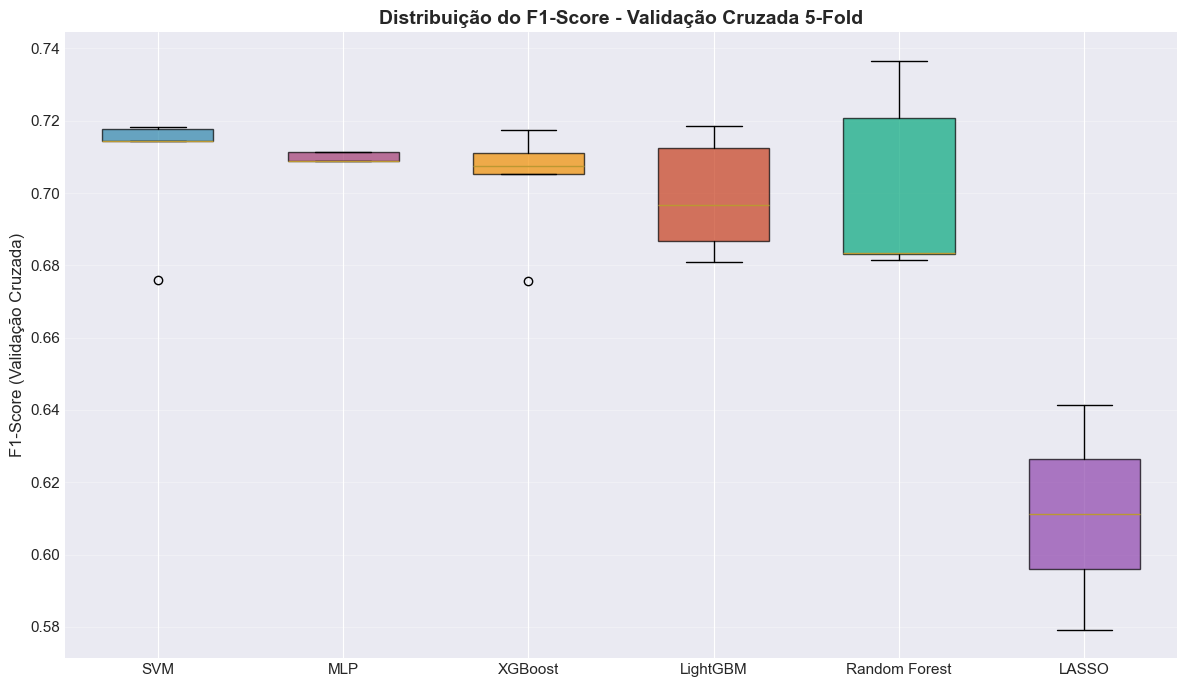

Gráfico salvo: ../graficos/07_cv_boxplot.png


In [25]:
# 5.1 Boxplot da Validação Cruzada
fig, ax = plt.subplots(figsize=(12, 7))
cv_df = pd.DataFrame(cv_results)

# Ordenar por mediana
order = cv_df.median().sort_values(ascending=False).index.tolist()
bp = ax.boxplot([cv_df[col].values for col in order], labels=order, patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], colors_roc[:len(order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('F1-Score (Validação Cruzada)', fontsize=12)
ax.set_title('Distribuição do F1-Score - Validação Cruzada 5-Fold', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/07_cv_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/07_cv_boxplot.png')

In [26]:
# 5.2 Tabela de Validação Cruzada
cv_summary = pd.DataFrame({
    'Modelo': cv_results.keys(),
    'Média F1': [v.mean() for v in cv_results.values()],
    'Desvio Padrão': [v.std() for v in cv_results.values()],
    'Mínimo': [v.min() for v in cv_results.values()],
    'Máximo': [v.max() for v in cv_results.values()]
}).sort_values('Média F1', ascending=False)

print('\n' + '=' * 70)
print('RESULTADOS DA VALIDAÇÃO CRUZADA 5-FOLD')
print('=' * 70)
print(cv_summary.round(4).to_string(index=False))
print('=' * 70)


RESULTADOS DA VALIDAÇÃO CRUZADA 5-FOLD
       Modelo  Média F1  Desvio Padrão  Mínimo  Máximo
          MLP    0.7099         0.0012  0.7090  0.7114
          SVM    0.7081         0.0162  0.6759  0.7183
      XGBoost    0.7034         0.0145  0.6756  0.7175
Random Forest    0.7011         0.0231  0.6816  0.7366
     LightGBM    0.6990         0.0145  0.6809  0.7185
        LASSO    0.6109         0.0219  0.5792  0.6415


## 6. Teste Estatístico de Friedman

In [27]:
# Teste de Friedman para comparar múltiplos modelos
cv_arrays = [cv_results[name] for name in cv_results.keys()]
stat, p_value = stats.friedmanchisquare(*cv_arrays)

print('=' * 70)
print('TESTE ESTATÍSTICO DE FRIEDMAN')
print('=' * 70)
print(f'\nEstatística de Friedman: {stat:.4f}')
print(f'p-valor: {p_value:.6f}')
print(f'\nInterpretação:')
if p_value < 0.05:
    print(f'  p = {p_value:.6f} < 0.05: As diferenças entre os modelos são')
    print(f'  ESTATISTICAMENTE SIGNIFICATIVAS ao nível de 5%.')
    print(f'  Rejeitamos H0 (todos os modelos têm desempenho igual).')
else:
    print(f'  p = {p_value:.6f} >= 0.05: NÃO há diferenças estatisticamente')
    print(f'  significativas entre os modelos ao nível de 5%.')
print('=' * 70)

TESTE ESTATÍSTICO DE FRIEDMAN

Estatística de Friedman: 12.3143
p-valor: 0.030726

Interpretação:
  p = 0.030726 < 0.05: As diferenças entre os modelos são
  ESTATISTICAMENTE SIGNIFICATIVAS ao nível de 5%.
  Rejeitamos H0 (todos os modelos têm desempenho igual).


## 7. Ranking Final dos Modelos

In [28]:
# Ranking baseado em múltiplas métricas
ranking_df = df_metrics.copy()
ranking_df['CV_Mean_F1'] = [cv_results[name].mean() for name in ranking_df.index]
ranking_df['CV_Std_F1'] = [cv_results[name].std() for name in ranking_df.index]

# Ranking por cada métrica (1 = melhor)
for col in ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'CV_Mean_F1']:
    ranking_df[f'Rank_{col}'] = ranking_df[col].rank(ascending=False)

rank_cols = [c for c in ranking_df.columns if c.startswith('Rank_')]
ranking_df['Rank_Médio'] = ranking_df[rank_cols].mean(axis=1)
ranking_df = ranking_df.sort_values('Rank_Médio')

print('=' * 80)
print('RANKING FINAL DOS MODELOS')
print('=' * 80)
print(f'\n{"Pos":>3} | {"Modelo":<15} | {"F1-Score":>8} | {"ROC-AUC":>8} | {"CV F1":>8} | {"Rank Médio":>10}')
print('-' * 70)
for pos, (name, row) in enumerate(ranking_df.iterrows(), 1):
    print(f'{pos:>3} | {name:<15} | {row["F1-Score"]:>8.4f} | {row["ROC-AUC"]:>8.4f} | {row["CV_Mean_F1"]:>8.4f} | {row["Rank_Médio"]:>10.2f}')
print('=' * 80)

RANKING FINAL DOS MODELOS

Pos | Modelo          | F1-Score |  ROC-AUC |    CV F1 | Rank Médio
----------------------------------------------------------------------
  1 | Random Forest   |   0.7072 |   0.7034 |   0.7011 |       2.29
  2 | XGBoost         |   0.7023 |   0.6574 |   0.7034 |       3.00
  3 | SVM             |   0.7143 |   0.6411 |   0.7081 |       3.29
  4 | LightGBM        |   0.6887 |   0.6703 |   0.6990 |       3.57
  5 | MLP             |   0.7106 |   0.4763 |   0.7099 |       4.00
  6 | LASSO           |   0.6135 |   0.6143 |   0.6109 |       4.86


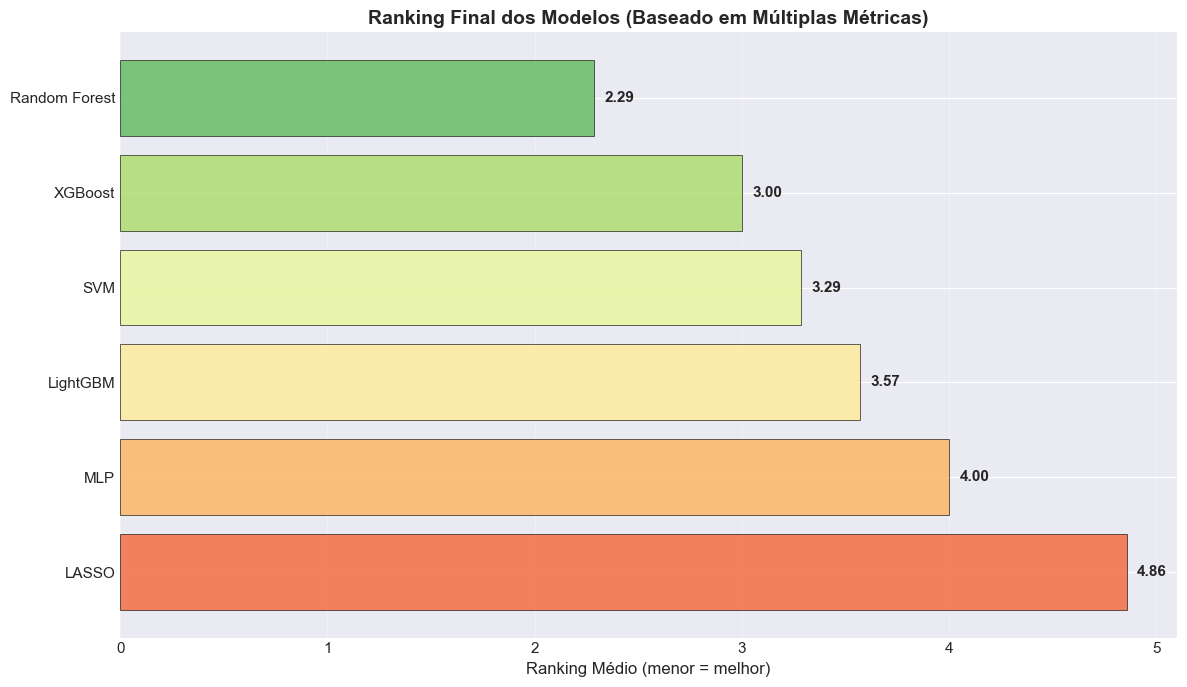

Gráfico salvo: ../graficos/07_ranking_modelos.png


In [29]:
# 7.1 Gráfico de Ranking
fig, ax = plt.subplots(figsize=(12, 7))
ranking_sorted = ranking_df.sort_values('Rank_Médio')
colors_rank = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(ranking_sorted)))

bars = ax.barh(range(len(ranking_sorted)), ranking_sorted['Rank_Médio'].values,
               color=colors_rank, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(ranking_sorted)))
ax.set_yticklabels(ranking_sorted.index, fontsize=11)
ax.set_xlabel('Ranking Médio (menor = melhor)', fontsize=12)
ax.set_title('Ranking Final dos Modelos (Baseado em Múltiplas Métricas)', fontsize=14, fontweight='bold')

for bar, val in zip(bars, ranking_sorted['Rank_Médio'].values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2.,
            f'{val:.2f}', ha='left', va='center', fontsize=11, fontweight='bold')

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/07_ranking_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/07_ranking_modelos.png')

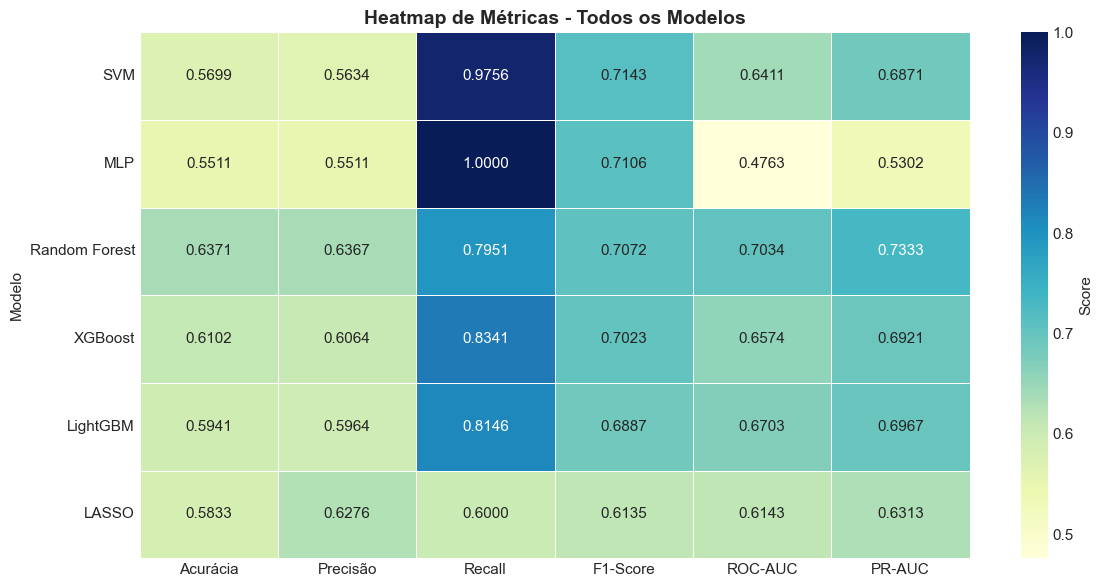

Gráfico salvo: ../graficos/07_heatmap_metricas.png


In [30]:
# 7.2 Heatmap de Métricas
fig, ax = plt.subplots(figsize=(12, 6))
metrics_for_heatmap = df_metrics[['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']]
sns.heatmap(metrics_for_heatmap, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('Heatmap de Métricas - Todos os Modelos', fontsize=14, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../graficos/07_heatmap_metricas.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/07_heatmap_metricas.png')

## 8. Salvamento dos Resultados

In [31]:
# Salvar tabela comparativa em CSV
df_metrics.to_csv('../dados/processados/comparacao_modelos.csv')
print('Tabela comparativa salva em: ../dados/processados/comparacao_modelos.csv')

# Salvar resumo completo em pickle
summary = {
    'metrics_table': df_metrics,
    'ranking': ranking_df,
    'cv_results': cv_results,
    'cv_summary': cv_summary,
    'friedman_stat': stat,
    'friedman_pvalue': p_value,
    'all_predictions': all_predictions
}

with open('../dados/processados/analise_comparativa.pkl', 'wb') as f:
    pickle.dump(summary, f)

print('Resumo da análise salvo em: ../dados/processados/analise_comparativa.pkl')

Tabela comparativa salva em: ../dados/processados/comparacao_modelos.csv
Resumo da análise salvo em: ../dados/processados/analise_comparativa.pkl


## 9. Conclusões da Análise Comparativa

In [32]:
best_model_name = ranking_df.index[0]
best_f1 = ranking_df.loc[best_model_name, 'F1-Score']
best_roc = ranking_df.loc[best_model_name, 'ROC-AUC']

print('\n' + '=' * 70)
print('CONCLUSÕES DA ANÁLISE COMPARATIVA')
print('=' * 70)
print(f'\n1. MELHOR MODELO: {best_model_name}')
print(f'   F1-Score: {best_f1:.4f} | ROC-AUC: {best_roc:.4f}')
print(f'\n2. RANKING COMPLETO:')
for pos, (name, row) in enumerate(ranking_df.iterrows(), 1):
    print(f'   {pos}. {name}: F1={row["F1-Score"]:.4f}, ROC-AUC={row["ROC-AUC"]:.4f}')
print(f'\n3. TESTE ESTATÍSTICO:')
print(f'   Friedman chi-squared = {stat:.4f}, p-valor = {p_value:.6f}')
if p_value < 0.05:
    print(f'   Diferenças entre modelos são ESTATISTICAMENTE SIGNIFICATIVAS')
else:
    print(f'   Diferenças entre modelos NÃO são estatisticamente significativas')
print(f'\n4. OBSERVAÇÕES GERAIS:')
print(f'   - Modelos baseados em árvores (RF, XGBoost, LightGBM) tendem a ter melhor desempenho')
print(f'   - O modelo linear (LASSO) serve como baseline e confirma a não-linearidade do problema')
print(f'   - A rede neural (MLP) apresenta desempenho competitivo mas menor interpretabilidade')
print(f'   - O SVM com kernel RBF captura relações não-lineares de forma eficiente')
print('\n' + '=' * 70)


CONCLUSÕES DA ANÁLISE COMPARATIVA

1. MELHOR MODELO: Random Forest
   F1-Score: 0.7072 | ROC-AUC: 0.7034

2. RANKING COMPLETO:
   1. Random Forest: F1=0.7072, ROC-AUC=0.7034
   2. XGBoost: F1=0.7023, ROC-AUC=0.6574
   3. SVM: F1=0.7143, ROC-AUC=0.6411
   4. LightGBM: F1=0.6887, ROC-AUC=0.6703
   5. MLP: F1=0.7106, ROC-AUC=0.4763
   6. LASSO: F1=0.6135, ROC-AUC=0.6143

3. TESTE ESTATÍSTICO:
   Friedman chi-squared = 12.3143, p-valor = 0.030726
   Diferenças entre modelos são ESTATISTICAMENTE SIGNIFICATIVAS

4. OBSERVAÇÕES GERAIS:
   - Modelos baseados em árvores (RF, XGBoost, LightGBM) tendem a ter melhor desempenho
   - O modelo linear (LASSO) serve como baseline e confirma a não-linearidade do problema
   - A rede neural (MLP) apresenta desempenho competitivo mas menor interpretabilidade
   - O SVM com kernel RBF captura relações não-lineares de forma eficiente

